**Data Inspection & Inspection:**
Loads all raw Landsat raster files and the Zürich West Quartier shapefiles (Kreise 3, 4, 5, 9, 10). Inspects raster metadata (CRS, resolution, band names, timestamps) and evaluates cloud cover per scene using the QA band or NoData proxy. Outputs a selection table of usable images for the next step.

In [10]:
%pip install rasterio xarray rioxarray geopandas numpy pandas scipy matplotlib contextily cmcrameri pymannkendall hvplot jupyter_bokeh netcdf4

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import necessary libraries
import os
import pathlib
import re
import rasterio
from rasterio.plot import show, show_hist
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**1.** Defining file paths and scan the data directory

In [3]:
# Define File paths
from pathlib import Path

DATA_RAW = Path("../data/raw/")

scene_paths = sorted(DATA_RAW.glob("*.tif*"))
                     
print(f"Found {len(scene_paths)} scenes:")
for p in scene_paths:
    print(f" {p.name}")

Found 14 scenes:
 LandsatComposite_Zurich_1985.tif
 LandsatComposite_Zurich_1988.tif
 LandsatComposite_Zurich_1991.tif
 LandsatComposite_Zurich_1994.tif
 LandsatComposite_Zurich_1997.tif
 LandsatComposite_Zurich_2000.tif
 LandsatComposite_Zurich_2003.tif
 LandsatComposite_Zurich_2006.tif
 LandsatComposite_Zurich_2009.tif
 LandsatComposite_Zurich_2012.tif
 LandsatComposite_Zurich_2015.tif
 LandsatComposite_Zurich_2018.tif
 LandsatComposite_Zurich_2021.tif
 LandsatComposite_Zurich_2024.tif


**2.** Inspect raster metadata

In [4]:
sample_path = scene_paths[0]

with rasterio.open(sample_path) as src:
    print("=== Raster Metadata ===")
    print(f"Driver:      {src.driver}")
    print(f"CRS:         {src.crs}")
    print(f"Resolution:  {src.res}")
    print(f"Dimensions:  {src.width} x {src.height} pixels")
    print(f"Band count:  {src.count}")
    print(f"Bounds:      {src.bounds}")
    print(f"NoData:      {src.nodata}")
    print(f"Band names:  {src.descriptions}")
    print(f"Tags:        {src.tags()}")   

=== Raster Metadata ===
Driver:      GTiff
CRS:         EPSG:32632
Resolution:  (30.0, 30.0)
Dimensions:  297 x 252 pixels
Band count:  7
Bounds:      BoundingBox(left=459960.0, bottom=5245110.0, right=468870.0, top=5252670.0)
NoData:      None
Band names:  ('Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'TIR1')
Tags:        {'AREA_OR_POINT': 'Area'}


**3.** Get timestamps from filenames

In [5]:
def extract_date_from_filename(filepath: Path) -> str:
    """
    Extract acquisition year from a  Ladsat filename and sets a fictitious summer day.
    Example: LandsatComposite_Zurich_1985.tif -> '1985-07-01'
    """
    name = filepath.stem
   
    match = re.search(r'(\d{4})', name)
    if match:
        year = match.group(1)
        return f"{year}-07-01"
    return "UNKNOWN"

print(extract_date_from_filename(scene_paths[0]))

1985-07-01


**4.** Loop over all scenes and build a metadata table

In [6]:
records = []

for path in scene_paths:
    with rasterio.open(path) as src:
        date = extract_date_from_filename(path)
        
        blue_band  = src.read(1).astype(float)  
        green_band = src.read(2).astype(float)  
        red_band   = src.read(3).astype(float)  
        nir_band   = src.read(4).astype(float)  
        swir1_band = src.read(5).astype(float)
        swir2_band = src.read(6).astype(float)  
        tir1_band  = src.read(7).astype(float)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            ndvi_band = (nir_band - red_band) / (nir_band + red_band)
    
        valid_mask = (blue_band > 0)

        blue_threshold = 0.20       # Clouds reflect more than 20% of blue light
        temp_threshold = 297.0      # Clouds are colder than 287 Kelvin

        cloud_mask = (
            (blue_band > blue_threshold) & 
            (ndvi_band > -0.1) & 
            (ndvi_band < 0.2) & 
            (tir1_band < temp_threshold) &
            valid_mask
        )
              
        valid_pixels_count = np.count_nonzero(valid_mask)
        cloud_pixels_count = np.count_nonzero(cloud_mask)
        
        if valid_pixels_count > 0:
            cloud_proxy_pct = (cloud_pixels_count / valid_pixels_count) * 100.0
        else:
            cloud_proxy_pct = 0.0
    
    
        records.append({
            "filename":       path.name,
            "date":           date,
            "crs":            str(src.crs),
            "resolution_m":   src.res[0],
            "band_count":     src.count,
            "width_px":       src.width,
            "height_px":      src.height,
            "nodata_value":   src.nodata,
            "cloud_pct":      round(cloud_proxy_pct, 1),})

meta_df = pd.DataFrame(records)
meta_df["date"] = pd.to_datetime(meta_df["date"])
meta_df = meta_df.sort_values("date").reset_index(drop=True)

print(meta_df.head())
print(f"\nShape: {meta_df.shape}")
meta_df.info()


                           filename       date         crs  resolution_m  \
0  LandsatComposite_Zurich_1985.tif 1985-07-01  EPSG:32632          30.0   
1  LandsatComposite_Zurich_1988.tif 1988-07-01  EPSG:32632          30.0   
2  LandsatComposite_Zurich_1991.tif 1991-07-01  EPSG:32632          30.0   
3  LandsatComposite_Zurich_1994.tif 1994-07-01  EPSG:32632          30.0   
4  LandsatComposite_Zurich_1997.tif 1997-07-01  EPSG:32632          30.0   

   band_count  width_px  height_px nodata_value  cloud_pct  
0           7       297        252         None        0.0  
1           7       297        252         None        0.0  
2           7       297        252         None        0.0  
3           7       297        252         None        0.0  
4           7       297        252         None        0.0  

Shape: (14, 9)
<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        -

-> The cloud percentage in the Landsat Tifs were always 0, so I assume they were cleaned beforehand



**5.** Load and inspect the "Statistische Quartiere" shapefile

Shapefile CRS:     EPSG:2056
Total features:    34
Columns:           ['objectid', 'qnr', 'qname', 'knr', 'kname', 'geometry']
   objectid  qnr       qname  knr    kname  \
0         1   73  Hirslanden    7  Kreis 7   
1         2   83     Weinegg    8  Kreis 8   
2         3   82   Mühlebach    8  Kreis 8   
3         4   81     Seefeld    8  Kreis 8   
4         7   41        Werd    4  Kreis 4   

                                            geometry  
0  POLYGON ((2684457.034 1246514.804, 2684466.315...  
1  POLYGON ((2684457.383 1246512.719, 2684458.291...  
2  POLYGON ((2684269.913 1246566.796, 2684271.618...  
3  POLYGON ((2683794.254 1246609.895, 2683802.117...  
4  POLYGON ((2682651.888 1247587.653, 2682650.697...  

Zürich West features: 12


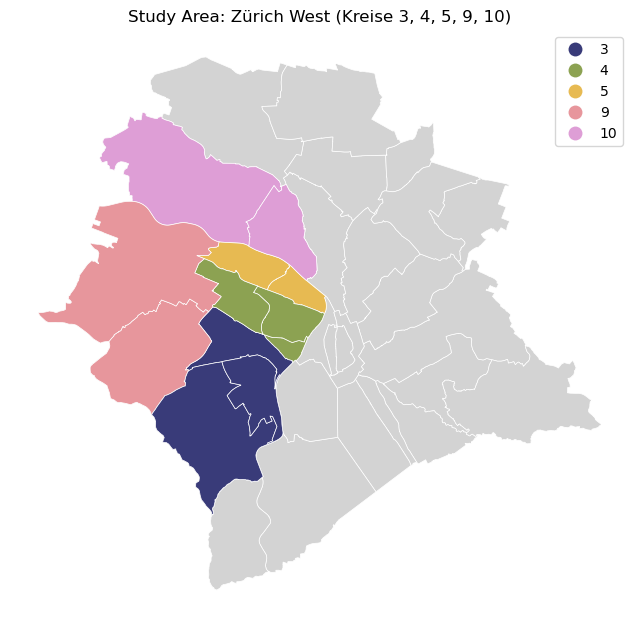

In [7]:
shapefile_path = Path("../data/vector/Statistische_Quartiere.gpkg")
gdf_all = gpd.read_file(
    shapefile_path, 
    layer="stzh.adm_statistische_quartiere_map"
)

print(f"Shapefile CRS:     {gdf_all.crs}")
print(f"Total features:    {len(gdf_all)}")
print(f"Columns:           {list(gdf_all.columns)}")
print(gdf_all.head())

zurich_west_kreise = [3, 4, 5, 9, 10]
gdf_zurich_west = gdf_all[gdf_all["knr"].isin(zurich_west_kreise)].copy()

print(f"\nZürich West features: {len(gdf_zurich_west)}")

fig, ax = plt.subplots(figsize=(8, 8))

gdf_all.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5)

gdf_zurich_west.plot(
    ax=ax, 
    column="knr", 
    categorical=True, 
    legend=True, 
    cmap="tab20b", 
    edgecolor="white", 
    linewidth=0.5
)

plt.title("Study Area: Zürich West (Kreise 3, 4, 5, 9, 10)")
plt.axis("off")

plt.savefig("../figures/01_study_area.png", dpi=300)
plt.show()


**7.** Export the usable scenes selection table

In [8]:
output_path = Path("../data/processed/01_usable_scenes.csv")

meta_df.to_csv(output_path, index=False)

print(f"Saved usable scene table to: {output_path}")

Saved usable scene table to: ../data/processed/01_usable_scenes.csv
